# Annual DWT probabilities

Load the saved DWT model and show the probability of each weather type by calendar year. Probabilities use the number of valid classified days as denominator; missing years remain blank and absent DWTs within observed years have probability zero.


In [1]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "climate_services/probabilistic/MUSCLE/outputs/dwt_model.pkl").is_file()
)
dwt_path = repo_root / "climate_services/probabilistic/MUSCLE/outputs/dwt_model.pkl"
with dwt_path.open("rb") as f:
    dwt_model = pickle.load(f)

print(f"Loaded {dwt_model.num_clusters} DWTs from {dwt_path.name}")


Loaded 36 DWTs from dwt_model.pkl


In [2]:
# Keep the model's original DWT numbering (1..36).
dwt_daily = dwt_model.kma_bmus["kma_bmus"].copy()
dwt_daily.index = pd.DatetimeIndex(pd.to_datetime(dwt_daily.index)).normalize()
dwt_daily = dwt_daily.dropna().sort_index()
if dwt_daily.empty or dwt_daily.index.has_duplicates:
    raise ValueError("Expected one DWT per day and a non-empty classified record.")
dwt_ids = pd.Index(range(1, dwt_model.num_clusters + 1), name="DWT")
if not dwt_daily.isin(dwt_ids).all():
    raise ValueError("DWT labels do not match the saved model's 1-based numbering.")
years = pd.Index(range(dwt_daily.index.year.min(), dwt_daily.index.year.max() + 1), name="Year")
annual_counts = pd.crosstab(dwt_daily.index.year, dwt_daily).reindex(
    index=years, columns=dwt_ids, fill_value=0,
)
valid_days = annual_counts.sum(axis=1)
annual_probability = annual_counts.div(valid_days.replace(0, np.nan), axis=0)
# Cumulative frequency pools all classified days from the start through each year.
cumulative_counts = annual_counts.cumsum()
cumulative_probability = cumulative_counts.div(
    cumulative_counts.sum(axis=1).replace(0, np.nan), axis=0,
).where(valid_days.gt(0), axis=0)
np.testing.assert_allclose(annual_probability.loc[valid_days.gt(0)].sum(axis=1), 1)
np.testing.assert_allclose(cumulative_probability.loc[valid_days.gt(0)].sum(axis=1), 1)
print(f"{len(dwt_daily):,} classified days: {dwt_daily.index.min().date()} to {dwt_daily.index.max().date()}")


17,167 classified days: 1979-01-01 to 2025-12-31


Each panel shows one calendar year, using a 6 × 6 grid of DWT probabilities and the same Blues color scale across all years. DWTs are arranged in their original numeric order, from left to right and top to bottom (1–36); this is a cluster layout, not a geographic map. Numbers inside cells identify the DWT. Each annual panel sums to 100%.


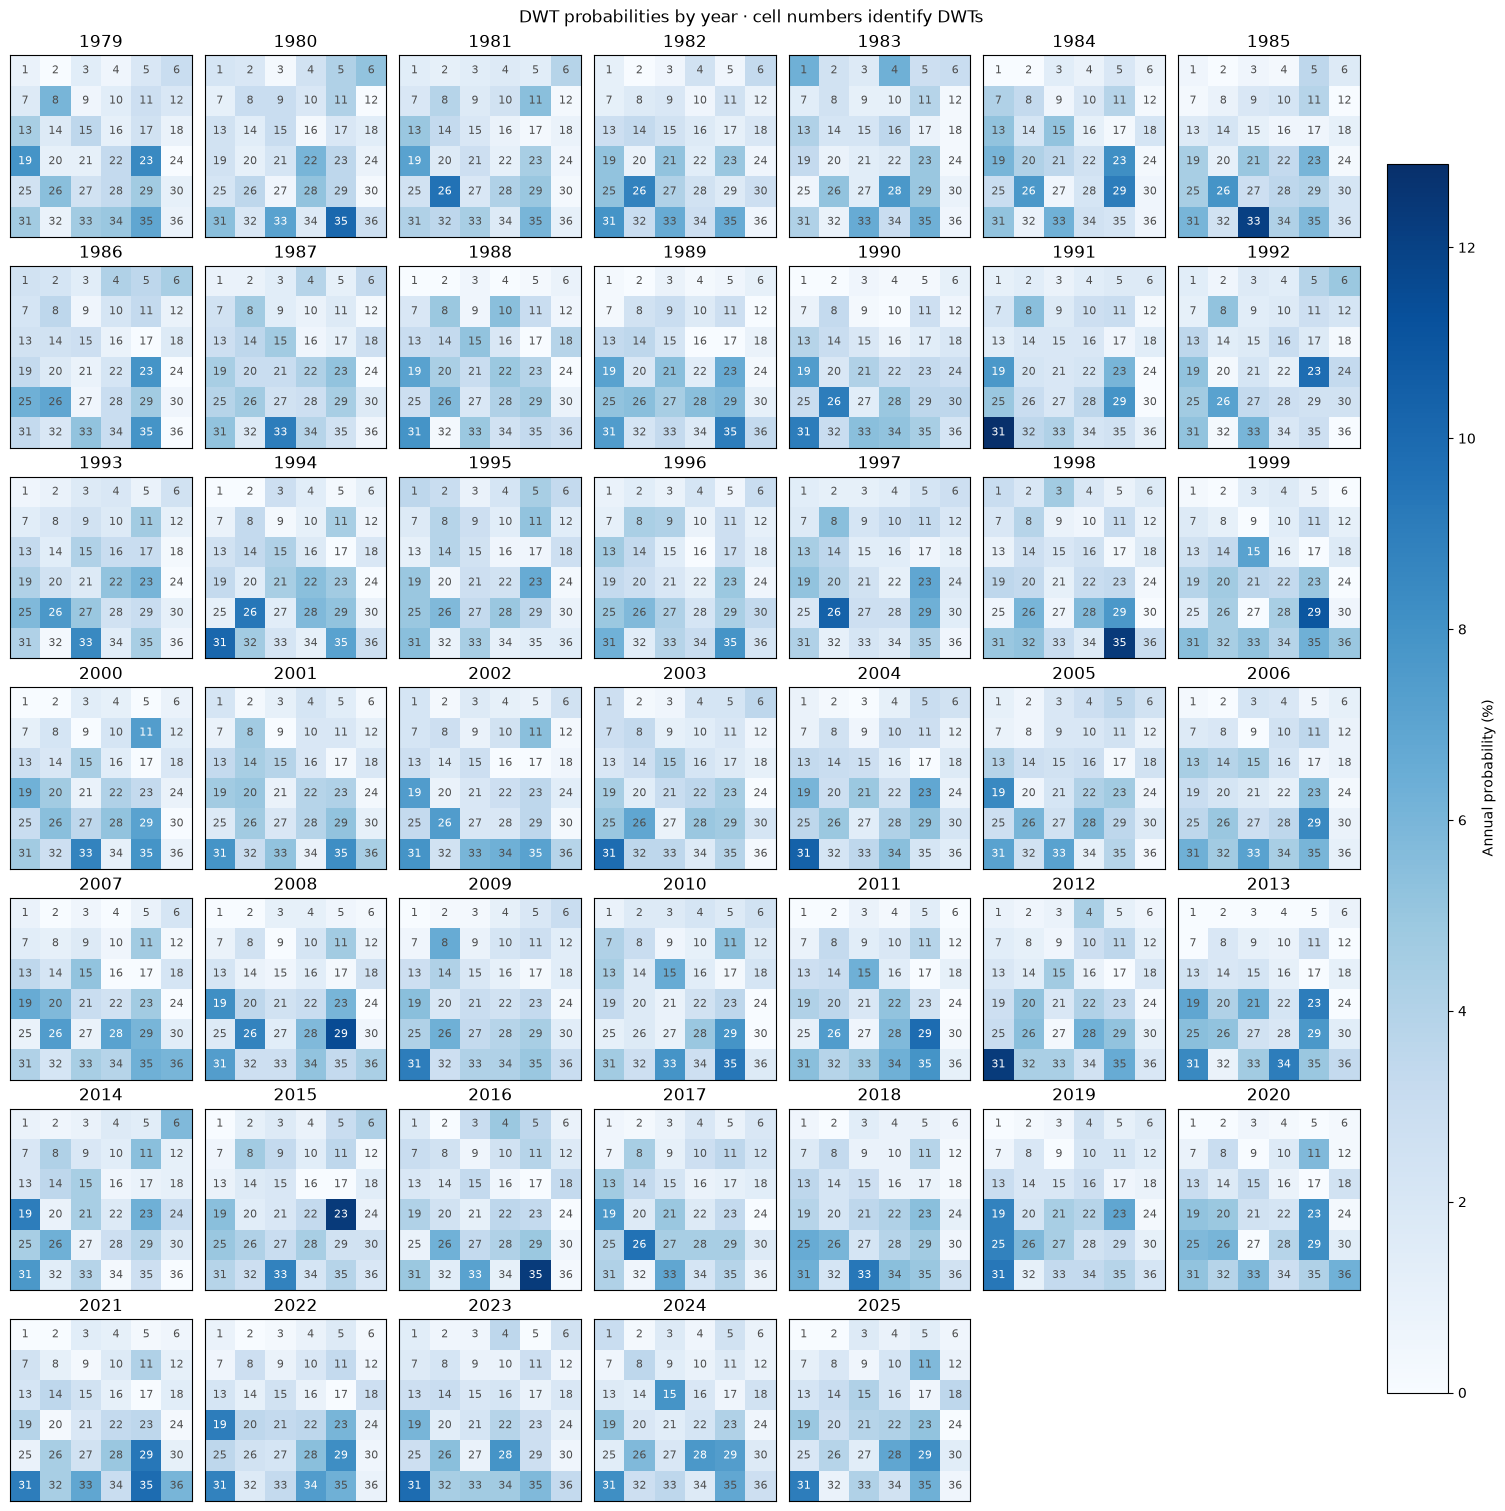

In [3]:
# One independent DWT probability map per year, arranged in a 7 × 7 grid.
probabilities = annual_probability * 100
n_dwt = len(dwt_ids)
grid_cols = int(np.ceil(np.sqrt(n_dwt)))
grid_rows = int(np.ceil(n_dwt / grid_cols))
plots_per_page = 49
panel_cols = 7
vmax = float(np.nanmax(probabilities.to_numpy()))
cmap = plt.get_cmap("Blues").copy()
cmap.set_bad("lightgrey")
annual_figures = []

for start in range(0, len(years), plots_per_page):
    page_years = years[start:start + plots_per_page]
    panel_rows = 7
    fig, axes = plt.subplots(panel_rows, panel_cols, figsize=(15, 15),
                             squeeze=False, layout="constrained")
    for ax, year in zip(axes.flat, page_years):
        values = np.full(grid_rows * grid_cols, np.nan)
        values[:n_dwt] = probabilities.loc[year].to_numpy()
        values = values.reshape(grid_rows, grid_cols)
        mesh = ax.imshow(values, cmap=cmap, vmin=0, vmax=vmax,
                         origin="upper", interpolation="nearest")
        for pos, dwt in enumerate(dwt_ids):
            row, col = divmod(pos, grid_cols)
            color = "white" if values[row, col] > 0.55 * vmax else "0.3"
            ax.text(col, row, str(dwt), ha="center", va="center", fontsize=8, color=color)
        ax.set_title(str(year))
        ax.set_xticks([])
        ax.set_yticks([])
    for ax in list(axes.flat)[len(page_years):]:
        ax.set_visible(False)
    fig.colorbar(mesh, ax=list(axes.flat)[:len(page_years)], shrink=0.85,
                 pad=0.02, label="Annual probability (%)")
    fig.suptitle("DWT probabilities by year · cell numbers identify DWTs")
    annual_figures.append(fig)
    plt.show()


## Annual probability anomalies

Annual probability minus the full-record (1979–2025) probability for each DWT, in percentage points. The reference weights every classified day equally. Red indicates more frequent occurrence and blue less frequent occurrence. All panels share a symmetric color scale centered on zero.


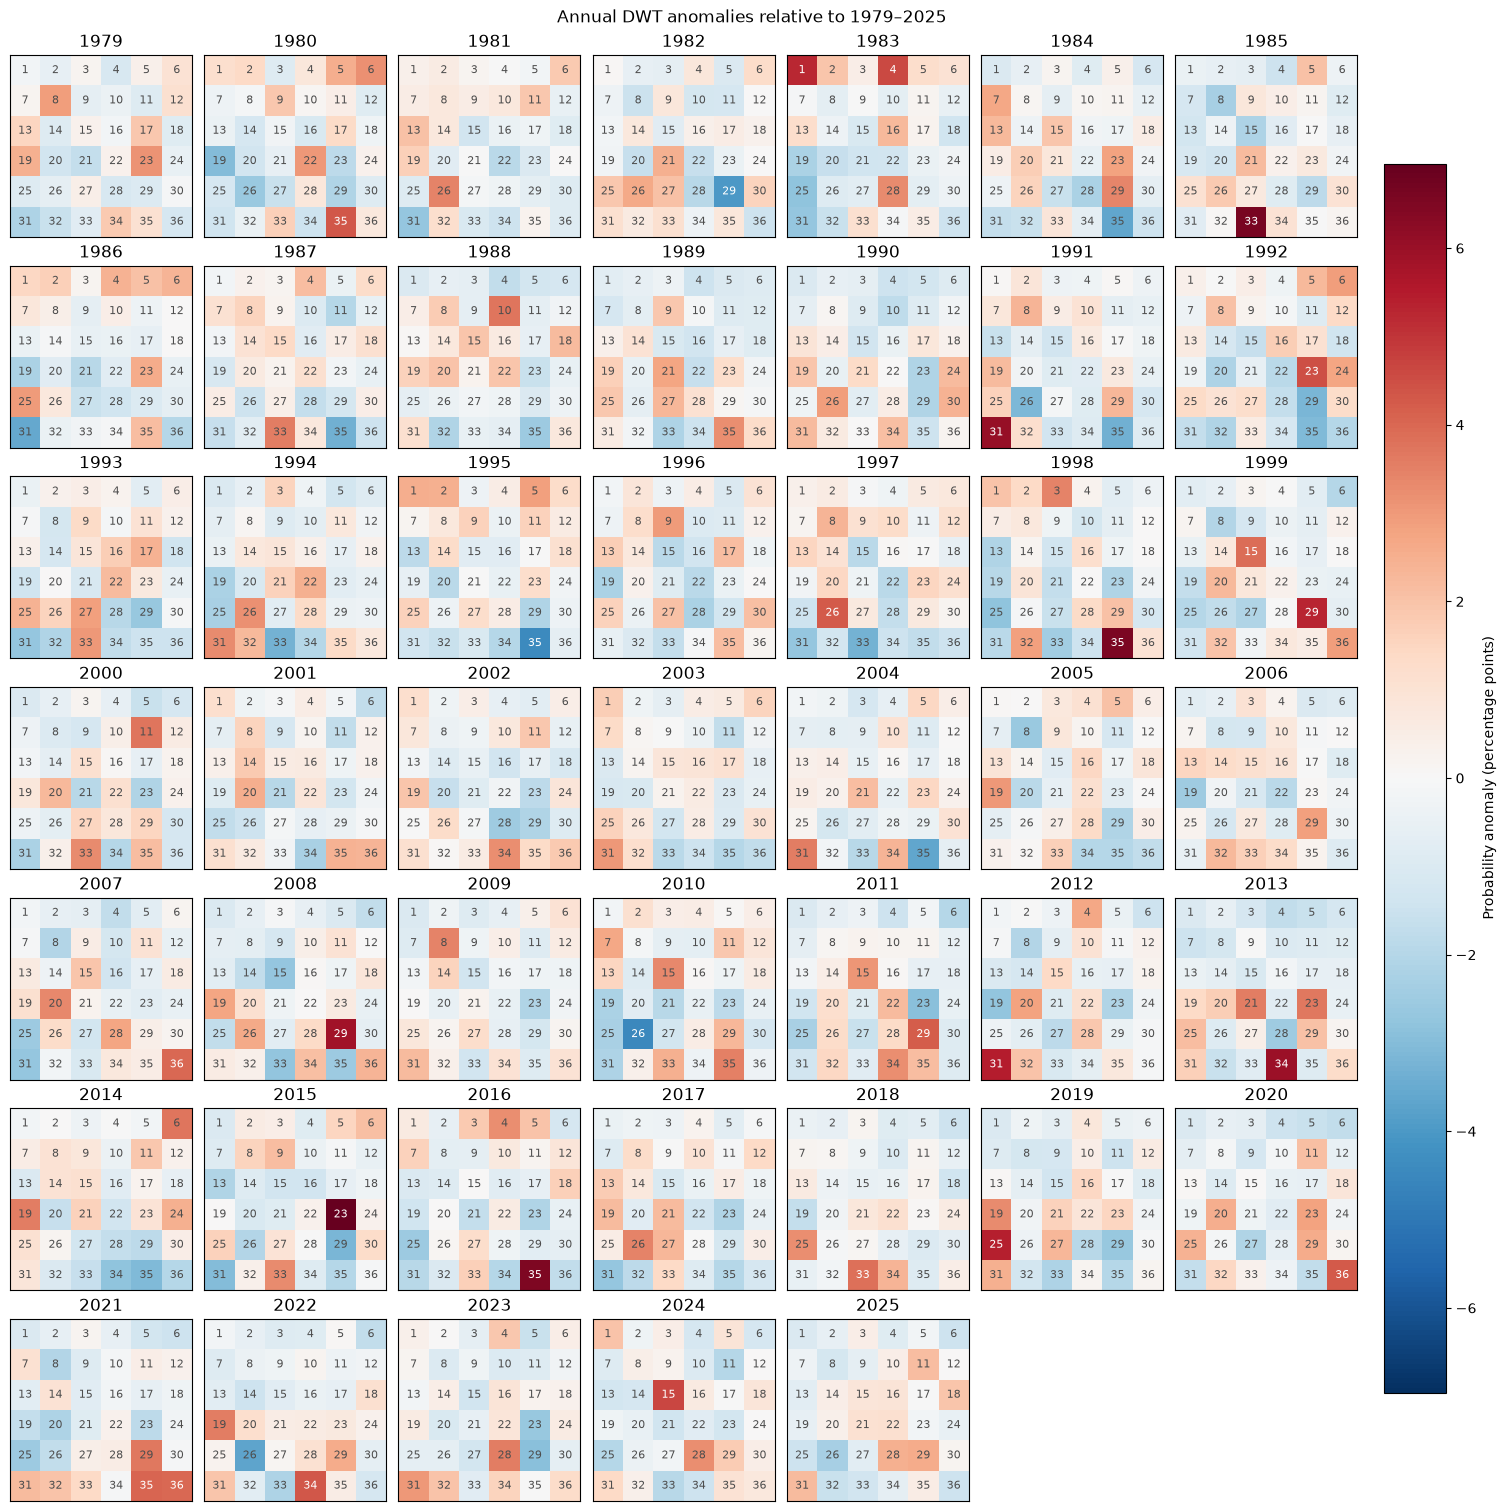

In [4]:
# Reference probabilities pool all classified days in 1979–2025.
climatology = annual_counts.sum(axis=0) / valid_days.sum()
annual_anomaly = annual_probability.subtract(climatology, axis="columns") * 100
np.testing.assert_allclose(annual_anomaly.loc[valid_days.gt(0)].sum(axis=1), 0, atol=1e-10)
probabilities = annual_anomaly
n_dwt = len(dwt_ids)
grid_cols = int(np.ceil(np.sqrt(n_dwt)))
grid_rows = int(np.ceil(n_dwt / grid_cols))
plots_per_page = 49
panel_cols = 7
vmax = max(float(np.nanmax(np.abs(probabilities.to_numpy()))), 1e-12)
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("lightgrey")
anomaly_figures = []

for start in range(0, len(years), plots_per_page):
    page_years = years[start:start + plots_per_page]
    panel_rows = 7
    fig, axes = plt.subplots(panel_rows, panel_cols, figsize=(15, 15),
                             squeeze=False, layout="constrained")
    for ax, year in zip(axes.flat, page_years):
        values = np.full(grid_rows * grid_cols, np.nan)
        values[:n_dwt] = probabilities.loc[year].to_numpy()
        values = values.reshape(grid_rows, grid_cols)
        mesh = ax.imshow(values, cmap=cmap, vmin=-vmax, vmax=vmax,
                         origin="upper", interpolation="nearest")
        for pos, dwt in enumerate(dwt_ids):
            row, col = divmod(pos, grid_cols)
            color = "white" if abs(values[row, col]) > 0.55 * vmax else "0.3"
            ax.text(col, row, str(dwt), ha="center", va="center", fontsize=8, color=color)
        ax.set_title(str(year))
        ax.set_xticks([])
        ax.set_yticks([])
    for ax in list(axes.flat)[len(page_years):]:
        ax.set_visible(False)
    fig.colorbar(mesh, ax=list(axes.flat)[:len(page_years)], shrink=0.85,
                 pad=0.02, label="Probability anomaly (percentage points)")
    fig.suptitle(f"Annual DWT anomalies relative to {years.min()}–{years.max()}")
    anomaly_figures.append(fig)
    plt.show()


## PCA of annual DWT probability anomalies

Use `bluemath_tk.datamining.pca.PCA` with years as observations and the 36 DWTs as features. Set `scale_data=False` to preserve the relative variance of anomalies in percentage points (covariance PCA). PCA centers each feature over the included years. Years with missing probabilities are excluded, not filled with zeros.

The first five EOFs retain the original 6 × 6 DWT layout. Each adjacent curve is its annual PC score; the title gives explained variance. EOF signs are arbitrary; interpret each EOF together with its PC.


In [5]:
import xarray as xr
from bluemath_tk.datamining.pca import PCA

pca_anomalies = annual_anomaly.dropna(axis=0, how="any")
if min(pca_anomalies.shape) < 5:
    raise ValueError("At least five complete years and five DWTs are needed.")
dwt_pca_input = xr.Dataset({
    "probability_anomaly": (("year", "dwt"), pca_anomalies.to_numpy()),
}, coords={"year": pca_anomalies.index.to_numpy(), "dwt": dwt_ids.to_numpy()})
dwt_pca_input.probability_anomaly.attrs["units"] = "percentage points"

annual_dwt_pca = PCA(n_components=5)
annual_dwt_pcs = annual_dwt_pca.fit_transform(
    data=dwt_pca_input,
    vars_to_stack=["probability_anomaly"],
    coords_to_stack=["dwt"],
    pca_dim_for_rows="year",
    scale_data=False,
)
annual_dwt_eofs = annual_dwt_pca.eofs.probability_anomaly
print(f"First five modes explain {annual_dwt_pca.explained_variance_ratio.sum():.1%} of annual anomaly variance")


Using 36 out of 36 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
Data is not standarized


First five modes explain 57.9% of annual anomaly variance


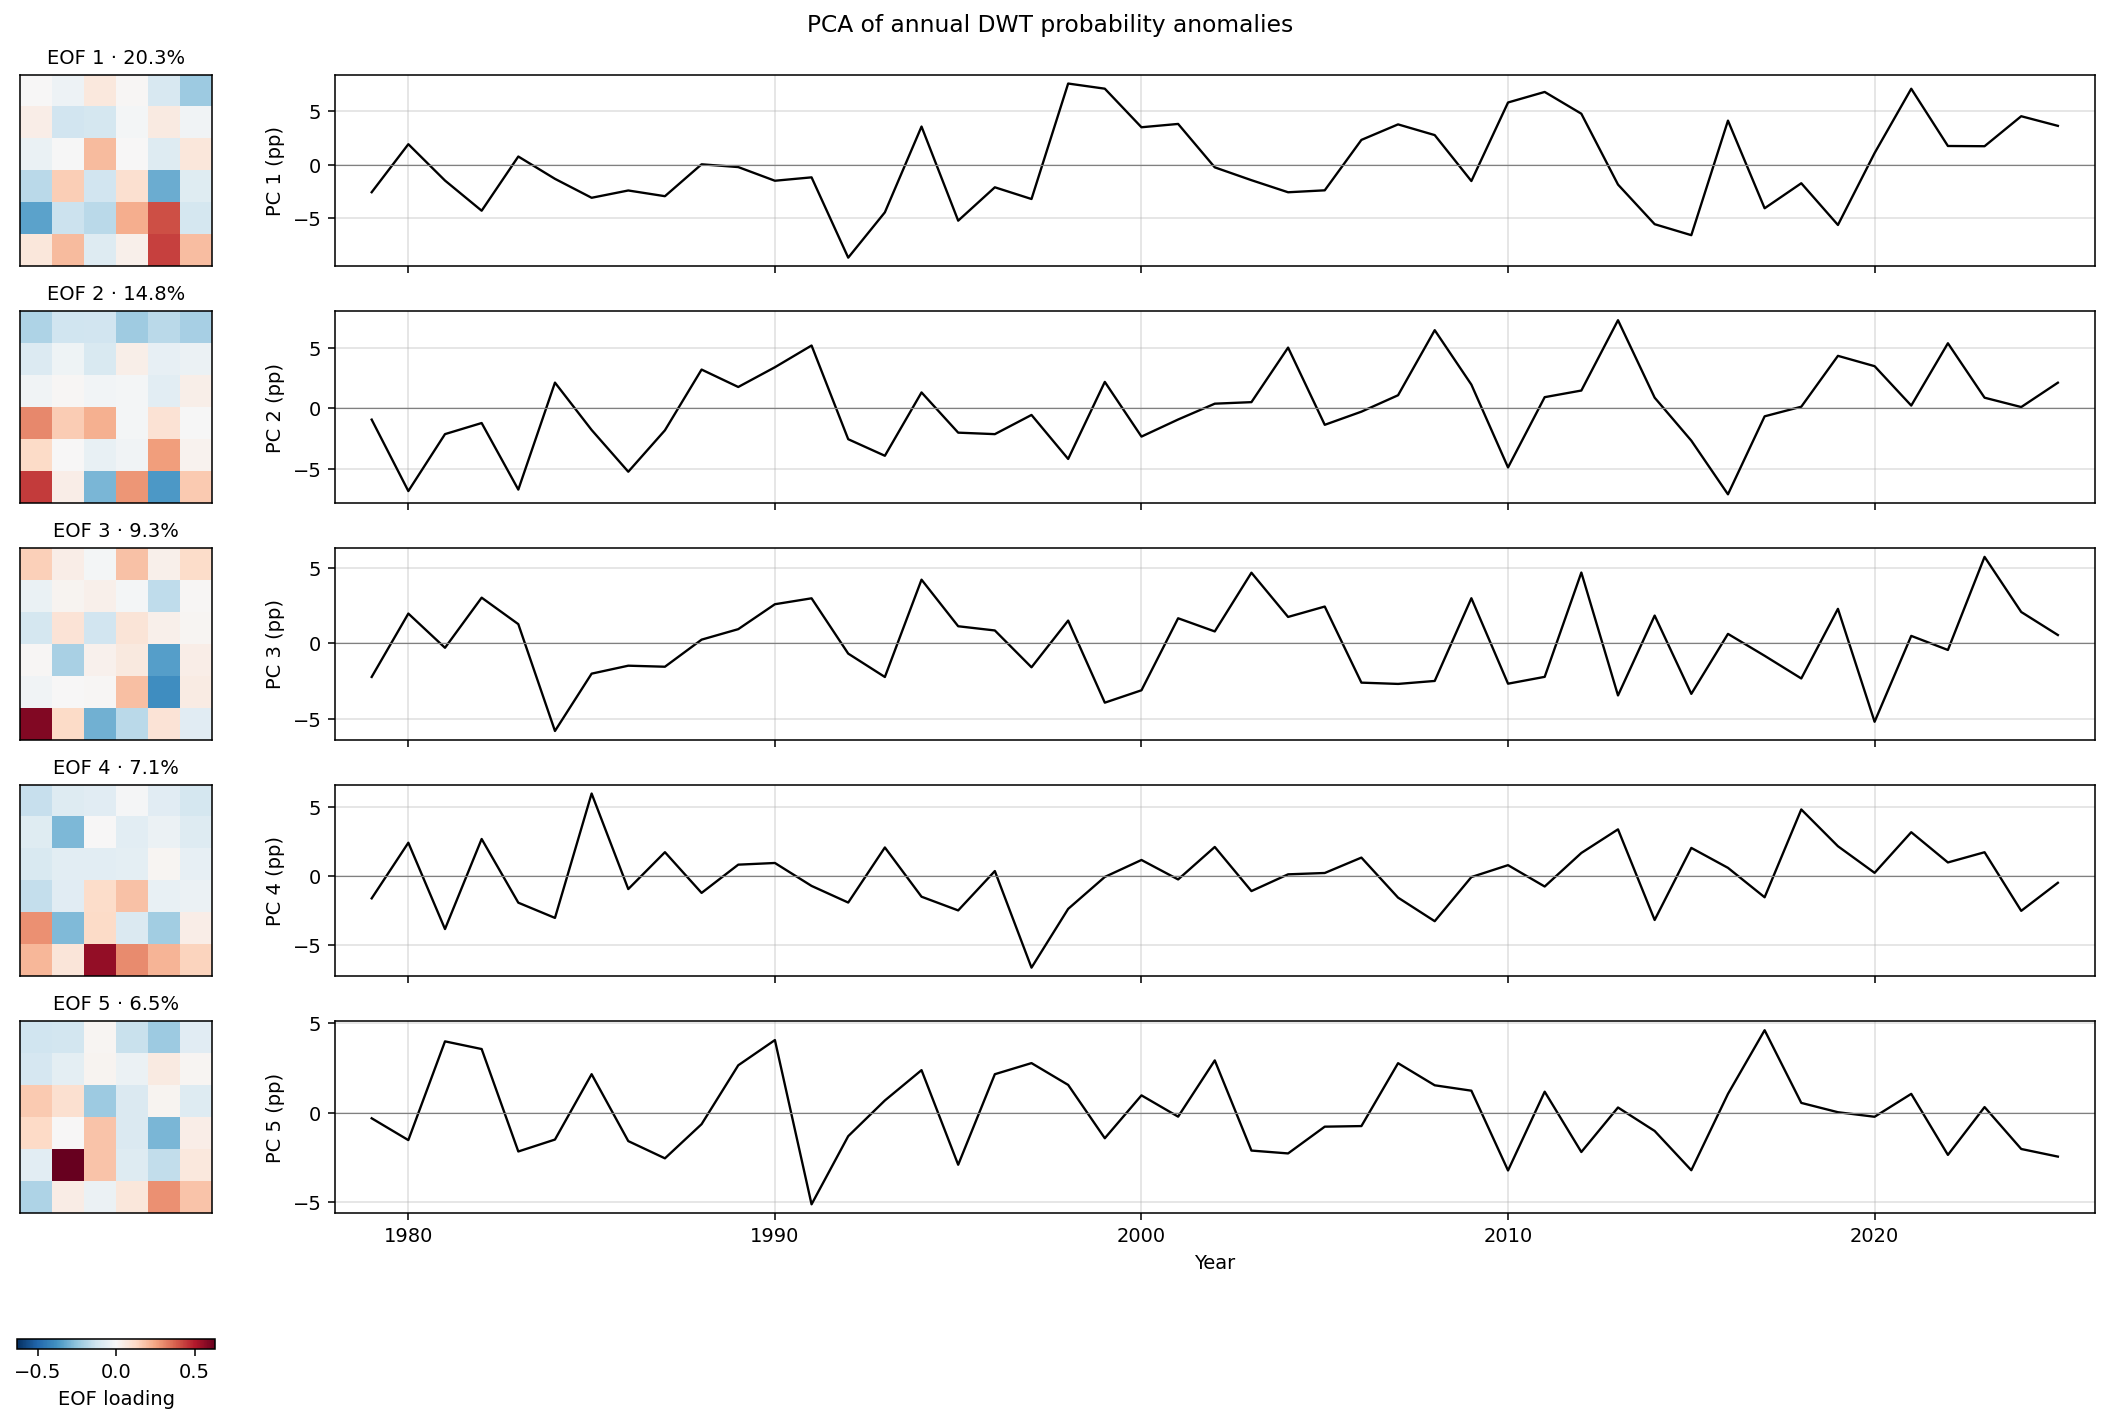

In [6]:
from matplotlib.colors import TwoSlopeNorm

n_modes = annual_dwt_pcs.sizes["n_component"]
fig_pca, axes_pca = plt.subplots(
    n_modes, 2, figsize=(15, 10), squeeze=False, layout="constrained",
    gridspec_kw={"width_ratios": [1, 8]},
)
eof_limit = float(np.abs(annual_dwt_eofs.values).max())
eof_norm = TwoSlopeNorm(vmin=-eof_limit, vcenter=0, vmax=eof_limit)
pc_years = annual_dwt_pcs.year.values

for mode, (ax_map, ax_pc) in enumerate(axes_pca):
    pattern = np.full(grid_rows * grid_cols, np.nan)
    pattern[:len(dwt_ids)] = annual_dwt_eofs.isel(n_component=mode).values
    eof_image = ax_map.imshow(pattern.reshape(grid_rows, grid_cols),
                              cmap="RdBu_r", norm=eof_norm, interpolation="nearest")
    ax_map.set(xticks=[], yticks=[])
    variance = annual_dwt_pca.explained_variance_ratio[mode] * 100
    ax_map.set_title(f"EOF {mode + 1} · {variance:.1f}%", fontsize=10)

    scores = annual_dwt_pcs.PCs.isel(n_component=mode).values
    ax_pc.plot(pc_years, scores, color="black", linewidth=1.2)
    ax_pc.axhline(0, color="0.5", linewidth=0.6)
    ax_pc.set_ylabel(f"PC {mode + 1} (pp)")
    ax_pc.grid(alpha=0.4)
    ax_pc.set_xlim(pc_years.min() - 1, pc_years.max() + 1)
    ax_pc.tick_params(labelbottom=mode == n_modes - 1)
axes_pca[-1, 1].set_xlabel("Year")
fig_pca.colorbar(eof_image, ax=list(axes_pca[:, 0]), location="bottom",
                 shrink=0.9, label="EOF loading")
fig_pca.suptitle("PCA of annual DWT probability anomalies")
plt.show()


## Relationship with tropical Pacific PC1 (ENSO)

Load `enso_pc1_monthly` saved by `PCA_ONI_index.ipynb`: tropical SST anomaly PC1, detrended and oriented to agree with Niño 3.4. This is a PCA-based ENSO proxy, not the official ONI. Average the monthly PC1 over each calendar year, requiring all 12 months, and align with the annual DWT PCs.

Compare all five DWT PCs at zero lag. Both series are standardized over the same complete shared years for display. Pearson correlations describe association within this record, not forecast skill; DWT EOF/PC signs remain as fitted. Annual averaging can suppress ENSO variations occurring within a year.


In [7]:
enso_indices_path = repo_root / "toolkit/datamining/outputs/era5_pacific_sst_indices_1979-2025_2deg.nc"
with xr.open_dataset(enso_indices_path) as saved_indices:
    tropical_pc1 = saved_indices["enso_pc1_monthly"].load().to_series()
tropical_pc1 = tropical_pc1.replace([np.inf, -np.inf], np.nan).sort_index()
if tropical_pc1.index.to_period("M").has_duplicates:
    raise ValueError("Expected a single tropical PC1 value per calendar month.")
annual_enso_pc1 = tropical_pc1.groupby(tropical_pc1.index.year).mean().where(
    tropical_pc1.groupby(tropical_pc1.index.year).count() == 12
).rename("ENSO_PC1")
dwt_scores = pd.DataFrame(
    annual_dwt_pcs.PCs.values, index=annual_dwt_pcs.year.values,
    columns=[f"DWT_PC{i + 1}" for i in range(annual_dwt_pcs.sizes["n_component"])],
)
enso_dwt_comparison = dwt_scores.join(annual_enso_pc1, how="inner").replace(
    [np.inf, -np.inf], np.nan
).dropna()
if len(enso_dwt_comparison) < 3 or (enso_dwt_comparison.std(ddof=1) == 0).any():
    raise ValueError("Need at least three shared years and nonconstant PCs.")
enso_dwt_standardized = (enso_dwt_comparison - enso_dwt_comparison.mean()) / enso_dwt_comparison.std(ddof=1)
enso_dwt_correlations = enso_dwt_comparison[dwt_scores.columns].corrwith(enso_dwt_comparison.ENSO_PC1)
print(f"Comparison: {len(enso_dwt_comparison)} complete shared years, "
      f"{enso_dwt_comparison.index.min()}–{enso_dwt_comparison.index.max()}")
print(enso_dwt_correlations.rename("Pearson r with tropical PC1"))


Comparison: 47 complete shared years, 1979–2025
DWT_PC1   -0.417614
DWT_PC2   -0.300223
DWT_PC3    0.311798
DWT_PC4   -0.078509
DWT_PC5   -0.097264
Name: Pearson r with tropical PC1, dtype: float64


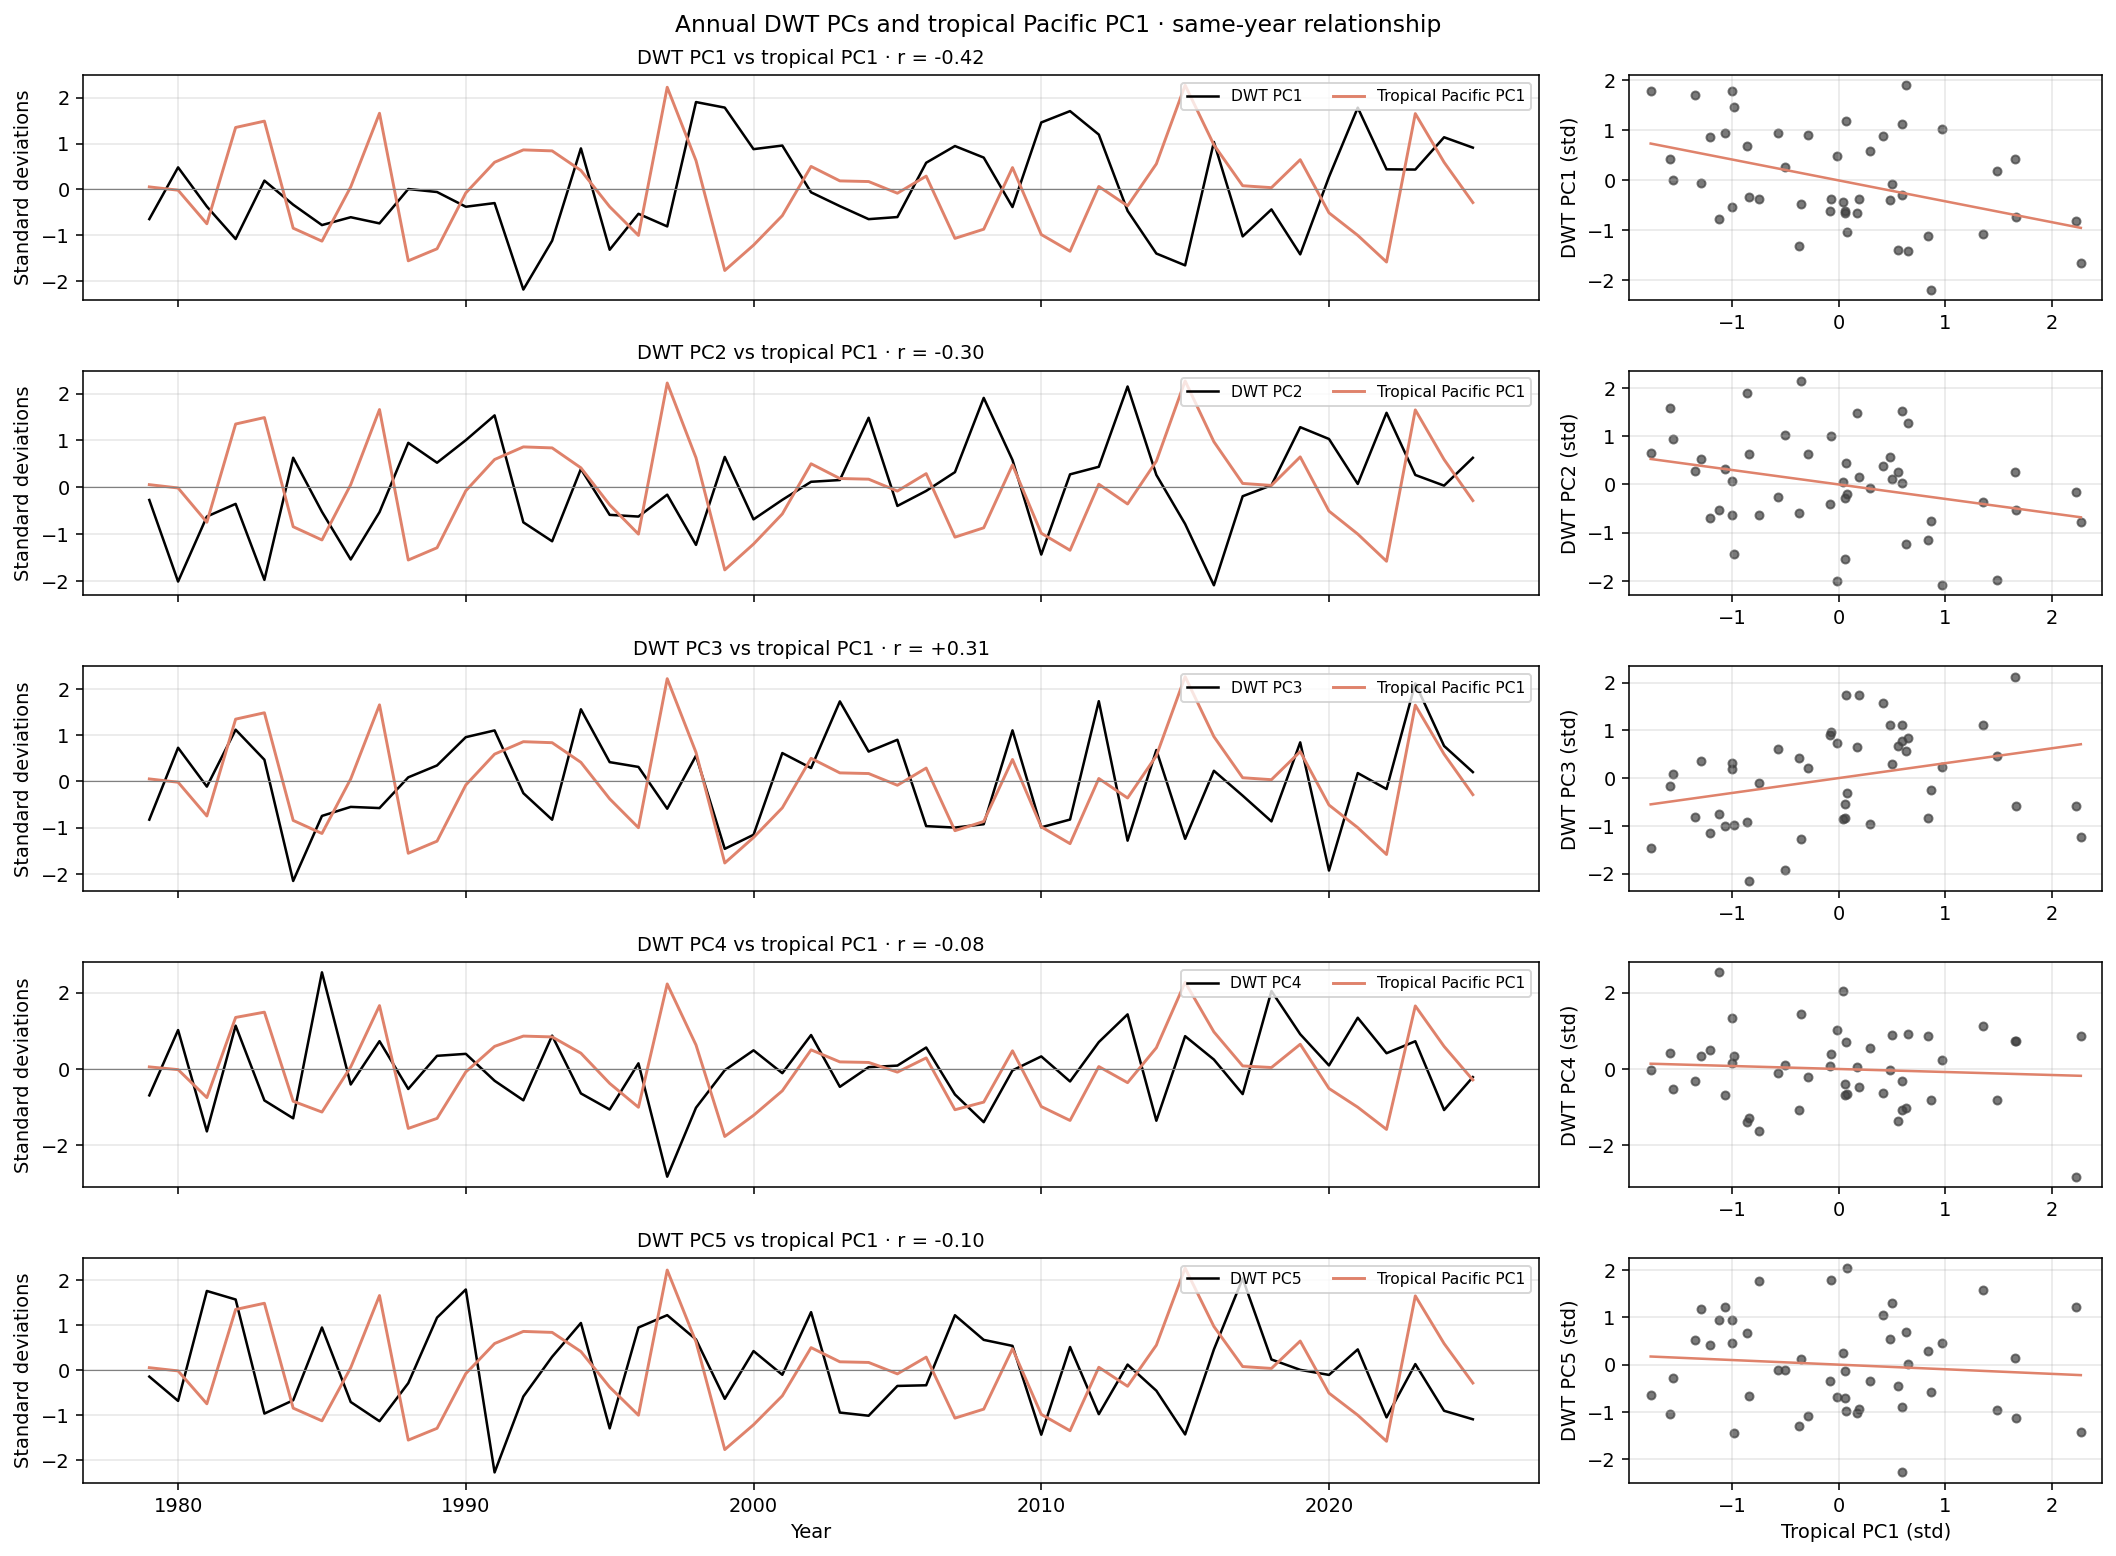

In [8]:
fig_enso_relation, axes_enso_relation = plt.subplots(
    len(dwt_scores.columns), 2, figsize=(15, 11), squeeze=False,
    layout="constrained", gridspec_kw={"width_ratios": [4, 1.3]},
)
enso_color = "#DF826B"
for i, column in enumerate(dwt_scores.columns):
    ax_time, ax_scatter = axes_enso_relation[i]
    paired = enso_dwt_standardized[[column, "ENSO_PC1"]]
    # Reindex only for the line plot, so missing years remain visible as gaps.
    timeline = paired.reindex(range(paired.index.min(), paired.index.max() + 1))
    ax_time.plot(timeline.index, timeline[column], color="black", linewidth=1.3, label=f"DWT PC{i + 1}")
    ax_time.plot(timeline.index, timeline.ENSO_PC1, color=enso_color, linewidth=1.5, label="Tropical Pacific PC1")
    ax_time.axhline(0, color="0.5", linewidth=0.6)
    ax_time.set_ylabel("Standard deviations")
    ax_time.set_title(f"DWT PC{i + 1} vs tropical PC1 · r = {enso_dwt_correlations[column]:+.2f}", fontsize=10)
    ax_time.grid(alpha=0.3)
    ax_time.legend(loc="upper right", fontsize=8, ncol=2)
    ax_time.tick_params(labelbottom=i == len(dwt_scores.columns) - 1)
    ax_scatter.scatter(paired.ENSO_PC1, paired[column], color="0.25", s=17, alpha=0.7)
    slope, intercept = np.polyfit(paired.ENSO_PC1, paired[column], 1)
    x_line = np.array([paired.ENSO_PC1.min(), paired.ENSO_PC1.max()])
    ax_scatter.plot(x_line, intercept + slope * x_line, color=enso_color, linewidth=1.3)
    ax_scatter.set_ylabel(f"DWT PC{i + 1} (std)")
    ax_scatter.grid(alpha=0.3)
axes_enso_relation[-1, 0].set_xlabel("Year")
axes_enso_relation[-1, 1].set_xlabel("Tropical PC1 (std)")
fig_enso_relation.suptitle("Annual DWT PCs and tropical Pacific PC1 · same-year relationship")
plt.show()


## Five clusters of years using BlueMath KMeans

Cluster years using their first five DWT PC scores with `bluemath_tk.datamining.kma.KMA`. Scores retain their original scale (`normalize_data=False`), preserving the variance weighting of the retained PCA subspace. Use a fixed seed and 50 initializations. Tropical PC1 is shown for comparison only and does not enter clustering.

Each year has one cluster color, repeated in all five PC panels and the tropical PC1 panel. Cluster numbers are arbitrary; for reproducible display they are ordered by centroid value along DWT PC1. The maps on the left are EOFs, not cluster centroids.


In [9]:
from bluemath_tk.datamining.kma import KMA
from IPython.display import display

annual_cluster_input = pd.DataFrame(
    annual_dwt_pcs.PCs.values, index=annual_dwt_pcs.year.values,
    columns=[f"PC{i + 1}" for i in range(annual_dwt_pcs.sizes["n_component"])],
)
annual_cluster_input.index.name = "year"
annual_kma = KMA(num_clusters=5, seed=42)
annual_kma.kma.set_params(n_init=50)
cluster_assignments, _ = annual_kma.fit_predict(
    data=annual_cluster_input.copy(), normalize_data=False,
)
cluster_order = annual_kma.centroids["PC1"].sort_values().index
cluster_mapping = {old: new for new, old in enumerate(cluster_order, start=1)}
year_clusters = cluster_assignments["kma_bmus"].map(cluster_mapping).rename("cluster")
cluster_colors = {1: "#0072B2", 2: "#E69F00", 3: "#009E73", 4: "#CC79A7", 5: "#D55E00"}
assert year_clusters.notna().all() and year_clusters.nunique() == 5
cluster_summary = pd.DataFrame({
    "n_years": year_clusters.value_counts().sort_index(),
    "years": year_clusters.groupby(year_clusters).apply(lambda group: ", ".join(map(str, group.index))),
})
display(cluster_summary)


INFO:KMA:Setting self.num_workers to 1. Change it using self.set_num_processors_to_use method.


INFO:KMA:KMA object created with 5 clusters and seed 42.To customize kma, do self.kma = dict(n_clusters=..., random_state=..., etc)
INFO:KMA:Normalization is disabled. Set normalize_data to True to enable normalization.
INFO:KMA:Proposed min custom scaler for PC1 is bigger than datapoint
INFO:KMA:Proposed max custom scaler for PC1 is lower than datapoint
INFO:KMA:Proposed min custom scaler for PC2 is bigger than datapoint
INFO:KMA:Proposed max custom scaler for PC2 is lower than datapoint
INFO:KMA:Proposed min custom scaler for PC3 is bigger than datapoint
INFO:KMA:Proposed max custom scaler for PC3 is lower than datapoint
INFO:KMA:Proposed min custom scaler for PC4 is bigger than datapoint
INFO:KMA:Proposed max custom scaler for PC4 is lower than datapoint
INFO:KMA:Proposed min custom scaler for PC5 is bigger than datapoint
INFO:KMA:Proposed max custom scaler for PC5 is lower than datapoint
INFO:KMA:Proposed min custom scaler for PC1 is bigger than datapoint
INFO:KMA:Proposed max cust

,n_years,years
cluster,,
1,9,"1979, 1986, 1987, 1992, 1993, 1995, 1997, 2014..."
2,14,"1981, 1982, 1985, 1989, 1990, 1996, 2002, 2003..."
3,8,"1984, 1988, 1991, 2004, 2008, 2013, 2020, 2022"
4,5,"1980, 1983, 1998, 2010, 2016"
5,11,"1994, 1999, 2000, 2001, 2006, 2007, 2011, 2012..."


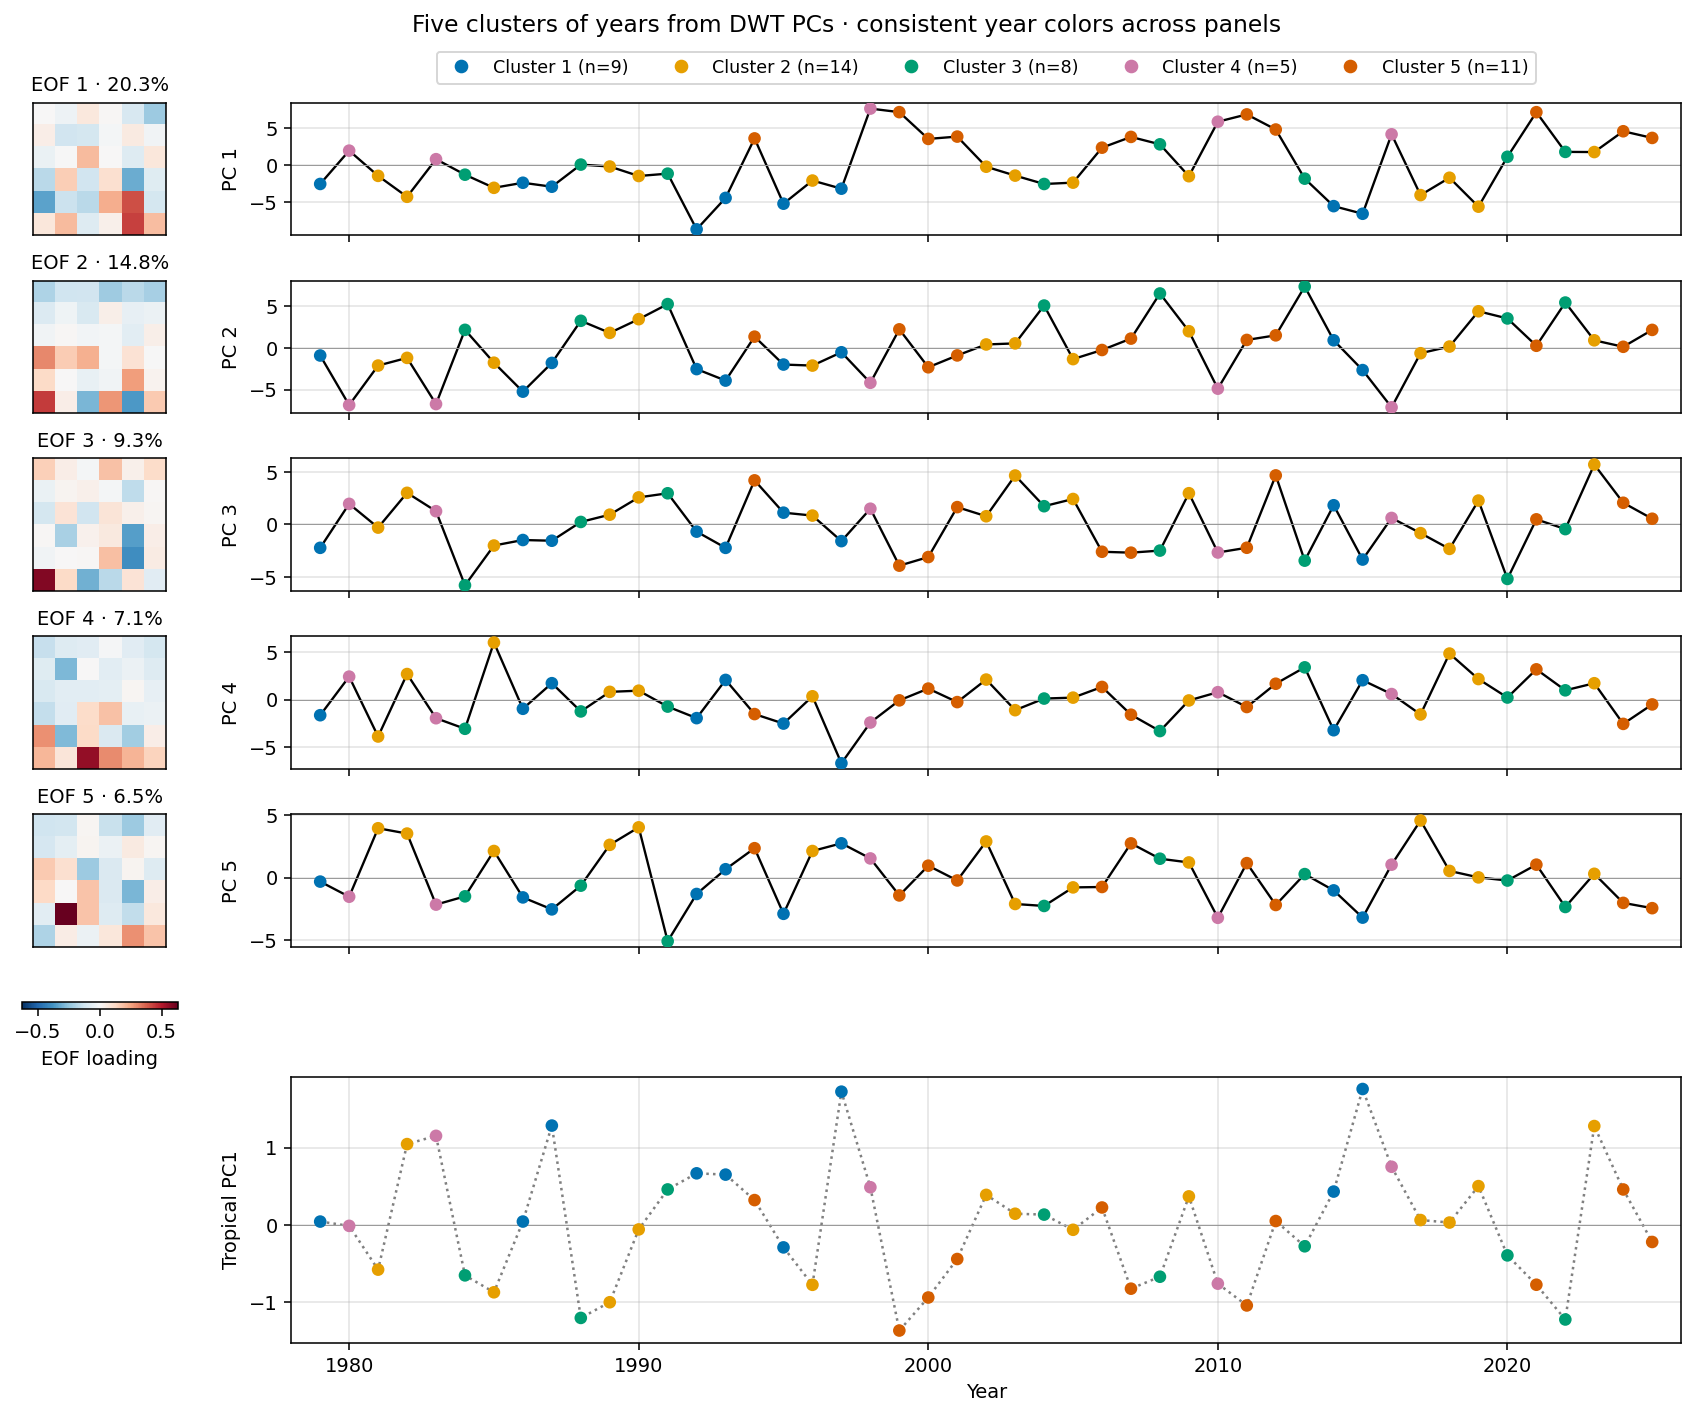

In [14]:
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

mode_count = annual_dwt_pcs.sizes["n_component"]
fig_year_clusters, axes_year_clusters = plt.subplots(
    mode_count + 1, 2, figsize=(12, 10), squeeze=False,
    layout="constrained", gridspec_kw={"width_ratios": [1, 8], "height_ratios": [1] * mode_count + [2]},
)
eof_limit = float(np.abs(annual_dwt_eofs.values).max())
eof_norm = TwoSlopeNorm(vmin=-eof_limit, vcenter=0, vmax=eof_limit)
plot_years = annual_cluster_input.index.to_numpy()
point_colors = year_clusters.map(cluster_colors).tolist()

for mode, (ax_map, ax_pc) in enumerate(axes_year_clusters[:-1]):
    pattern = np.full(grid_rows * grid_cols, np.nan)
    pattern[:len(dwt_ids)] = annual_dwt_eofs.isel(n_component=mode).values
    eof_image = ax_map.imshow(pattern.reshape(grid_rows, grid_cols),
                              cmap="RdBu_r", norm=eof_norm, interpolation="nearest")
    ax_map.set(xticks=[], yticks=[])
    variance = annual_dwt_pca.explained_variance_ratio[mode] * 100
    ax_map.set_title(f"EOF {mode + 1} · {variance:.1f}%", fontsize=10)
    scores = annual_cluster_input.iloc[:, mode]
    ax_pc.plot(plot_years, scores, color="black", linewidth=1.2)
    ax_pc.scatter(plot_years, scores, c=point_colors, s=30, zorder=3)
    ax_pc.set_ylabel(f"PC {mode + 1}")

axes_year_clusters[-1, 0].set_visible(False)
ax_enso = axes_year_clusters[-1, 1]
enso_by_year = annual_enso_pc1.reindex(plot_years)
ax_enso.plot(plot_years, enso_by_year, color="0.5", linestyle=":", linewidth=1.3)
ax_enso.scatter(plot_years, enso_by_year, c=point_colors, s=30, zorder=3)
ax_enso.set(ylabel="Tropical PC1", xlabel="Year")
for row, ax in enumerate(axes_year_clusters[:, 1]):
    ax.axhline(0, color="0.6", linewidth=0.5)
    ax.grid(alpha=0.35)
    ax.set_xlim(plot_years.min() - 1, plot_years.max() + 1)
    ax.tick_params(labelbottom=row == mode_count)
legend_handles = [Line2D([], [], marker="o", linestyle="none", color=cluster_colors[k],
                         label=f"Cluster {k} (n={int((year_clusters == k).sum())})")
                  for k in cluster_colors]
axes_year_clusters[0, 1].legend(handles=legend_handles, ncol=5, loc="upper center",
                               bbox_to_anchor=(0.5, 1.45), fontsize=9)
fig_year_clusters.colorbar(eof_image, ax=list(axes_year_clusters[:-1, 0]),
                           location="bottom", shrink=0.9, label="EOF loading")
fig_year_clusters.suptitle("Five clusters of years from DWT PCs · consistent year colors across panels")
plt.show()


In [ ]:
# Export the annual DWT PCs for the sea-level regression notebook.
pc_output_path = repo_root / "toolkit/regression/outputs/annual_dwt_pcs.nc"
pc_output_path.parent.mkdir(parents=True, exist_ok=True)
exported_pcs = annual_dwt_pcs.copy()
exported_pcs["explained_variance_ratio"] = ("n_component", annual_dwt_pca.explained_variance_ratio)
exported_pcs.attrs.update(
    source_notebook="MMSL_regression.ipynb", source_model=str(dwt_path),
    description="Annual DWT probability anomaly PCA; calendar years; no feature scaling",
    pc_units="percentage points", annual_alignment="January through December",
)
exported_pcs.to_netcdf(pc_output_path)
print(f"Saved annual DWT PCs: {pc_output_path.name}")
